# Comparaison des méthodes de calcul du coefficien de retard (ou resistance) du lit

In [1]:
# module automatic reload
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import libtfr
import multitaper
import numpy as np
import pandas as pd
import xarray as xr
from scipy.signal import detrend

# plotting
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib as mpl
import seaborn as sns

sns.set_theme('notebook', style='ticks')
plt.style.use("dark_background")
plt.rcParams.update({
    "figure.facecolor":  (0, 0, 0, 0),
    "axes.facecolor":    (0, 0, 0, 0),
    "savefig.facecolor": (0, 0, 0, 0),
})
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler('color',
    ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
)


# multitaper

sys.path.append('../../../PycharmProjects/orca5')
import src.wangwoerman.wangwoerman as ww
from src.model.hallmoench import (
    get_impulse_response, get_impulse_response2
)

In [3]:
def power_bit_length(x):
    return int(2**(x-1).bit_length())


def load_signal(h5, from_date=None, until_date=None, sampling_period='H'):
    s = pd.HDFStore(h5).raw_xarr_nanta.value
    s = s.astype('float')
    s.index = pd.to_xarr_nantetime(s.index)
    s.index.name = 'xarr_nantetime'
    s = s.tz_localize(None)
    return s[from_xarr_nante:until_xarr_nante].asfreq('H')


def resample_signal(sig, sampling_period='H'):
    s = sig.dropna().resample('H').mean().resample('H').interpolate()
    s = pd.Series(index=s.index, data=detrend(s.values))
    return s


def get_spectrogram(sig, nfft, nw, k, window, shift):
    nframes = (sig.size - window) // shift + 1
    slices = [(x, x + window) for x in np.arange(nframes) * shift]
    frames_ok = np.array(
        [np.isnan(sig.values[slice(*s)]).sum() < 0.05 * np.diff(s)[0]
         for s in slices]
    )
    indices = np.arange(nframes) * shift + window // 2
    # create a transform object
    D = libtfr.mfft_dpss(nfft, nw, k, window)
    sig = resample_signal(sig, sampling_period=f'{pd.infer_freq(sig.index)}')
    Fs = 1 / pd.to_timedelta(f'1{pd.infer_freq(sig.index)}').total_seconds()
    f, _ = libtfr.fgrid(Fs, D.nfft)
    Z = D.mtspec(sig, shift)
    return sig.index[indices], f, np.where(frames_ok, Z, np.nan)


def cut_spectrogram(x, y, Z, xmin=None, xmax=None, ymin=None, ymax=None):
    if xmin is None:
        xmin = x.min()
    if xmax is None:
        xmax = x.max()
    if ymin is None:
        ymin = y.min()
    if ymax is None:
        ymax = y.max()
    xmask = (x >= xmin) & (x <= xmax)
    ymask = (y >= ymin) & (y <= ymax)
    return x[xmask], y[ymask], Z[ymask, :][:, xmask]


def plot_spectrogram(x, y, Z,
                     ylabel=None, cblabel=None,
                     cmap='gnuplot2', norm=mcolors.LogNorm(),
                     cbar=False,
                     figsize=None,
                     ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    pcm = ax.pcolormesh(x, y, Z, cmap=cmap, norm=norm)
    ax.xaxis.set_major_locator(mdates.YearLocator(base=1))
    ax.set_ylabel(ylabel)
    if cbar:
        cax = plt.colorbar(pcm, ax=ax)
        cax.set_label(cblabel)
    return ax, pcm


def load_rl_and_gh_data(rl_h5, gh_h5, from_date=None, until_date=None, sampling_period='H'):
    sig_with_nan = {}
    Zdict = {}
    for l, v in zip(['gh', 'rl'], [gh_h5, rl_h5]):
        sig_with_nan[l] = load_signal(
            v, from_date, until_date, sampling_period)
        if from_date is None and l == 'gh':
            from_date = sig_with_nan[l].index[0]
        if until_date is None and l == 'gh':
            until_date = sig_with_nan[l].index[-1]

    index_min = max(sig_with_nan['rl'].index[0],
                    sig_with_nan['gh'].index[0])
    index_max = min(sig_with_nan['rl'].index[-1],
                    sig_with_nan['gh'].index[-1])

    for l in ['gh', 'rl']:
        sig_with_nan[l] = sig_with_nan[l][index_min: index_max]

    return sig_with_nan


def get_rl_and_gh_spectograms(sig_with_nan, nfft, nw, k, window, shift):
    Zdict = {}

    for l in ['gh', 'rl']:
        dates, freqs, Zdict[l] = get_spectrogram(
            sig_with_nan[l], nfft, nw, k, window, shift)

    return dates, freqs, Zdict


def plot_rl_and_gh_spectrograms(dates, freqs, Zdict,
                                ylabel=None, cblabel=None, cbar=False,
                                cmap='gnuplot2',
                                figsize=(12, 4)):
    fig, ax = plt.subplots(2, 1, sharex=True, figsize=figsize)
    Z_val = np.array([Zdict[k] for k in ['rl', 'gh']]).flatten().flatten()

    vmin, vmax = np.nanmin(Z_val), np.nanmax(Z_val)
    cbar = True
    norm = mcolors.LogNorm(vmin, vmax)
    for i, k in enumerate(['rl', 'gh']):
        plot_spectrogram(
            dates, freqs, Zdict[k], ylabel, cblabel, cmap, norm, cbar, figsize, ax=ax[i]
        )
    return fig, ax


def g_mean(x):
    a = np.log10(x)
    return 10**(np.nanmean(a, axis=0))


def plot_series_spetra_a(ser_dict, spec_dict, R_dict, figsize=(11, 6), cmap='viridis'):
    # global
    fig, axd = plt.subplot_mosaic(
        [['sp0', 'none0'], ['sp1', 'cax12'], ['sp2', 'cax12'],
            ['sp3', 'cax3'], ['sp4', 'none4']],
        gridspec_kw={'width_ratios': [30, 1],
                     'height_ratios': [2, 1, 1, 1, 4]},
        figsize=figsize)  # , layout="constrained")
    plt.subplots_adjust(hspace=0.2, wspace=0.05)
    [v.remove() for k, v in axd.items() if 'none' in k]

    # sp0
    for k in ['rl', 'gh']:
        sig_minus_mean = sig_with_nan[k]-sig_with_nan[k].mean()
        axd['sp0'].plot(sig_minus_mean.index, sig_minus_mean, label='k')
        axd['sp0'].set_ylabel('level-mean [m]')

    # sp1, sp2
    Z_val = np.array([spec_dict[k]['Z']
                     for k in ['rl', 'gh']]).flatten().flatten()
    vmin, vmax = np.nanmin(Z_val), np.nanmax(Z_val)
    for i, k in enumerate(['rl', 'gh']):
        pcm = plot_spectrogram(
            spec_dict[k]['dates'], spec_dict[k]['freqs'], spec_dict[k]['Z'],
            cmap=cmap, norm=mcolors.LogNorm(vmin, vmax), ax=axd[f'sp{i+1}']
        )
    fig.colorbar(mappable=pcm[1], cax=axd['cax12'], label=f'PSD [m$^2$ day]')
    axd['sp2'].set_ylabel('f [cycle/day]')

    # sp3
    pcm = plot_spectrogram(
        R_dict['dates'], R_dict['freqs'], R_dict['R'],
        cmap=f'{cmap}_r', norm=mcolors.LogNorm(), ax=axd['sp3']
    )
    fig.colorbar(mappable=pcm[1], cax=axd['cax3'], label='R [m]')

    # sp4
    # np.mean(R_dict['R'], axis=0))
    axd['sp4'].semilogy(dates, g_mean(R_dict['R']))
    axd['sp4'].set_ylabel('R [m]')
    axd['sp4'].set_xlim(dates[0], dates[-1])
    axd['sp4'].xaxis.set_major_locator(mdates.YearLocator(base=1))

    # global
    for k, v in axd.items():
        if k not in ['sp4', 'cax12', 'cax3', 'none0', 'none4']:
            plt.setp(v.get_xticklabels(), visible=False)
            v.sharex(axd['sp4'])
        v.set_axisbelow(True)
        if k not in ['sp4']:
            v.grid(False)
        else:
            v.grid(True)

    return fig, ax


In [4]:
def load_signal(h5, name, from_date=None, until_date=None, sampling_period='H') -> pd.Series:
    """
    Load series. Format time and numbers. Fill gaps.
    """
    s = pd.HDFStore(h5).raw_data.value
    s.name = name
    s = s.astype('float')
    s.index = pd.to_datetime(s.index)
    s.index.name = 'datetime'
    s = s.tz_localize(None)
    s = s[from_date:until_date]
    s = s.asfreq(sampling_period)
    return s


def load_rl_gh_signals(rl_h5, gh_h5, from_date=None, until_date=None, sampling_period='H') -> pd.DataFrame:
    """
    Load river and groundwater signals. Cut them so that they overlap.
    """
    data = pd.concat((
        load_signal(rl_h5, 'rl', from_date, until_date, sampling_period),
        load_signal(gh_h5, 'gh', from_date, until_date, sampling_period)
    ), axis=1, join='inner')

    return data


def get_slices(twin, dt, olap, df):
    nwin = int(np.round(twin / dt))
    if olap <= 0.0:
        njump = nwin
    else:
        njump = int(np.round(twin * (1.0 - olap) / dt))
    nmax = len(df) - nwin
    nvec = np.arange(0, nmax, njump)
    nspec = len(nvec)
    slices = np.array([slice(i*njump, i*njump+nwin) for i in range(nspec)])
    slices_ok = np.array([df.iloc[sl].isna().any(
        axis=1).sum() < 0.1*njump for sl in slices])
    middle_indices = np.array([(sl.start + sl.stop) // 2 for sl in slices])
    return slices, slices_ok, middle_indices


def set_to_nan(mat, slices_ok):
    mat1 = mat
    mat1[:, ~slices_ok] = np.nan
    return mat1


def hs_estimator(s, Pxx, Pyy, Pyx, Pxy):

    Hsa = s**2 * Pxx - Pyy + np.sqrt(
        (s**2 * Pxx - Pyy)
        + 4 * s**2 * np.abs(Pyx)**2
    ) / (2 * s**2 * Pyx)

    Hsb = 2 * Pxy / (
        Pyy
        - s**2 * Pxx
        + np.sqrt(
            (s**2 * Pxx - Pyy)
            + 4 * s**2 * np.abs(Pyx)**2
        )
    )
    return Hsa, Hsb


def sliding_trf_fit(
    data, dt, twin, olap=0.5, nw=3.5, kspec=5, fmin=0.0, fmax=-1.0,
    iadapt=0, vn=None, lamb=None, wl=0.0, a=10, x=45
):
    """
    Computes a cross-spectrogram with consecutive multitaper estimates.
    Returns both Thomson's multitaper and the Quadratic multitaper estimate

    **Parameters**

    data : array_like (npts, 2)
        Time series or sequence
    dt : float
        Sampling interval in seconds of the time series.
    twin : float
        Time duration in seconds of each segment for a single multitaper estimate.
    olap : float, optional
        Overlap requested for the segment in building the spectrogram.
        Defaults = 0.5, values must be (0.0 - 0.99).
        Overlap rounds to the nearest integer point.
    nw : float, optional
        Time-bandwidth product for Thomson's multitaper algorithm.
        Default = 3.5
    kspec : int, optional
        Number of tapers for avearaging the multitaper estimate.
        Default = 5
    fmin : float, optional
        Minimum frequency to estimate the spectrogram, otherwise returns the
        entire spectrogram matrix.
        Default = 0.0 Hz
    fmax : float, optional
        Maximum frequency to estimate the spectrogram, otherwise returns the
        entire spectrogram matrix.
        Default = 0.5/dt Hz (Nyquist frequency)
    iadapt : integer, optional
        User defined, determines which method for multitaper averaging to use.
        Default = 0
        0 - Adaptive multitaper
        1 - Eigenvalue weights
        2 - Constant weighting
    wl : float, optional
        water-level for stabilizing deconvolution (transfer function).
        defined as proportion of mean power of Syy

    **Returns**

    f : ndarray
        Array of sample frequencies.
    t : ndarray
        Array of segment times.
    Quad : ndarray
        Spectrogram of x using the quadratic multitaper estimate.
    MT : ndarray
        Spectrogram of x using Thomson's multitaper estimate.

    By default, the last axis of Quad/MT corresponds to the segment times.

    **See Also**

    MTSpec: Multitaper estimate of a time series.

    **Notes**

    The code assumes a real input signals and thus mainly returns the positive
    frequencies. For a complex input signals, code qould require adaptation.

    **References**

       Prieto, G.A. (2022). The multitaper spectrum analysis package in Python.
       Seism. Res. Lett In review.

    **Examples**

    To do

    |

    """

    from scipy.optimize import curve_fit

    data_is_df = False
    if isinstance(data, pd.DataFrame):
        data_is_df = True
        if data.index.freq is not None:
            dt = pd.to_timedelta(data.index.freq).total_seconds()

    if fmax <= 0.0:
        fmax = 0.5 / dt

    nwin = int(np.round(twin / dt))
    if olap <= 0.0:
        njump = nwin
    else:
        njump = int(np.round(twin * (1.0 - olap) / dt))

    npts = np.shape(data)[0]
    nmax = npts - nwin
    nvec = np.arange(0, nmax, njump)
    t = nvec * dt  # window starting times in seconds
    nspec = len(nvec)
    nvars = 8

    if data_is_df:
        t_middle = data.index[0] + pd.to_timedelta(t, unit='seconds')  # window middle datetime
        data = data.to_numpy()
    else:
        t_middle = t + twin // 2  # window middle times in seconds    

    print("Window length %5.1fs and overlap %2.0f%%" % (twin, olap * 100))
    print("Total number of cross-spectral estimates", nspec)
    print("Frequency band of interest (%5.2f-%5.2f)Hz" % (fmin, fmax))

    if vn is None or lamb is None:
        vn, lamb = multitaper.utils.dpss(nwin, nw, kspec)

    import time

    def ww2019_7(omega, log10R):
        R = np.power(10., log10R)
        F = np.exp(-np.sqrt(1j * omega / a) * x) / (1 + R * np.sqrt(1j * omega / a))
        return F.real

    def ww2019_8(omega, log10R):
        R = np.power(10., log10R)
        P = np.exp(-np.sqrt(2 * omega / a) * x) / (R ** 2 * omega / a + R * np.sqrt(2 * omega / a) + 1)
        return P

    def ptrf(freq, log10a):
        t = np.arange(1, int(1e6), 1)
        dt = t[1]-t[0]
        x = 45
        alpha=10
        green = get_impulse_response(t.size, x, alpha*dt, np.power(10.0, log10a))
        freq2 = np.fft.fftshift(np.fft.fftfreq(t.size, d=dt))
        trf = np.fft.fftshift(np.fft.fft(green).real)
        trf = trf[freq2>0]
        freq2 = freq2[freq2>0]
        trf2 = np.interp(freq, freq2, trf)
        return trf2

    for i in range(nspec):
        if (i + 1) % 10 == 0:
            print("Loop ", i + 1, " of ", nspec)

        i1 = nvec[i]
        i2 = i1 + nwin

        cpsd = multitaper.MTCross(
            data[i1: i2 + 1, 0],  # x: independent/explanatory variable
            data[i1: i2 + 1, 1],  # y: dependent/response variable 
            nw,
            kspec,
            dt,
            iadapt=iadapt,
            vn=vn,
            lamb=lamb,
            wl=wl,
        )

        freq2 = cpsd.freq

        nf = len(freq2)

        if i == 0:

            fres = np.where((freq2 >= fmin) & (freq2 <= fmax))[0]
            nf = len(fres)
            f = freq2[fres]

            omega = 2 * np.pi * f

            ds = xr.DataArray(
                np.ones((nspec, nvars)) * np.nan,
                dims=('t', 'var'),
                coords=dict(t=t_middle, var=['R_T', 'R_H1', 'cov_T', 'cov_H1', 'R_T_ww', 'R_H1_ww', 'cov_T_ww', 'cov_H1_ww'])
            )

        if np.isnan(data[i1: i2 + 1, :]).sum() > 0.1 * nwin:
            continue

        H1 = cpsd.Syx / cpsd.Sxx
        T  = np.sqrt(cpsd.Syy) / np.sqrt(cpsd.Sxx)

        res_H1 = curve_fit(ptrf, f.flatten(), H1[fres, 0].real, p0=[3,])
        res_T = curve_fit(ptrf, f.flatten(), T[fres, 0].real, p0=[3,])

        res_H1_ww = curve_fit(ww2019_7, omega.flatten(), H1[fres, 0].real, p0=[3,])
        res_T_ww = curve_fit(ww2019_7, omega.flatten(), T[fres, 0].real, p0=[3,])

        ds.sel(var='R_T')[i] = np.power(10., res_T[0][0])
        ds.sel(var='cov_T')[i] = res_T[1][0,0]
        ds.sel(var='R_H1')[i] = np.power(10., res_H1[0][0])
        ds.sel(var='cov_H1')[i] = res_H1[1][0,0]

        ds.sel(var='R_T_ww')[i] = np.power(10., res_T_ww[0][0])
        ds.sel(var='cov_T_ww')[i] = res_T_ww[1][0,0]
        ds.sel(var='R_H1_ww')[i] = np.power(10., res_H1_ww[0][0])
        ds.sel(var='cov_H1_ww')[i] = res_H1_ww[1][0,0]

    return ds


In [5]:
# load river and groundwater signals
sig = load_rl_gh_signals(
    '../../../PycharmProjects/orca5/data/raw_data/hydro/2346_518_2002_1859.h5',
    '../../../PycharmProjects/orca5/data/raw_data/piezo/150_head_bsl.h5',
    from_date='2011-04-04', until_date=None, sampling_period='H'
)
print(sig.head())
sig_interp = sig.dropna().resample('H').mean().resample('H').interpolate()

                          rl      gh
datetime                            
2011-04-04 00:00:00  665.672  643.84
2011-04-04 01:00:00  665.671  643.84
2011-04-04 02:00:00  665.669  643.84
2011-04-04 03:00:00  665.665  643.84
2011-04-04 04:00:00  665.661  643.84


In [6]:
# cross-spectrogram parameters
data = sig_interp.to_numpy()
npts = data.shape[0]
nw = 12
k = 3*nw-1
twin = 1*28*24*60**2
olap = 0.75
dt = 60**2
slices, slices_ok, indices = get_slices(twin, dt, olap, sig)
print(f'{slices.size=}')
print(f'{slices_ok.sum()=}')


slices.size=603
slices_ok.sum()=550


In [7]:
ucf = 24*dt
trf_fit = sliding_trf_fit(
    data=sig_interp, dt=dt, twin=twin, olap=0.5, nw=3.5, kspec=5, fmin=(2/3)/ucf, fmax=1/ucf,
    iadapt=0, vn=None, lamb=None, wl=0.0, a=10, x=45
)

Window length 2419200.0s and overlap 50%
Total number of cross-spectral estimates 302
Frequency band of interest ( 0.00- 0.00)Hz


KeyboardInterrupt: 

NameError: name 'trf_fit' is not defined

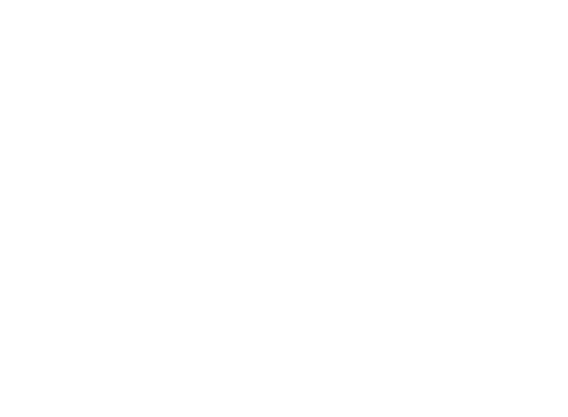

In [6]:
fig, ax = plt.subplots()
ax.set_yscale('log')
trf_fit.sel(var=['R_H1']).plot(ax=ax, lw=5)
trf_fit.sel(var=['R_T']).plot(ax=ax, lw=5)
trf_fit.sel(var=['R_H1_ww']).plot(ax=ax)
trf_fit.sel(var=['R_T_ww']).plot(ax=ax)
ax.set_ylim(1e-1, 1e6)

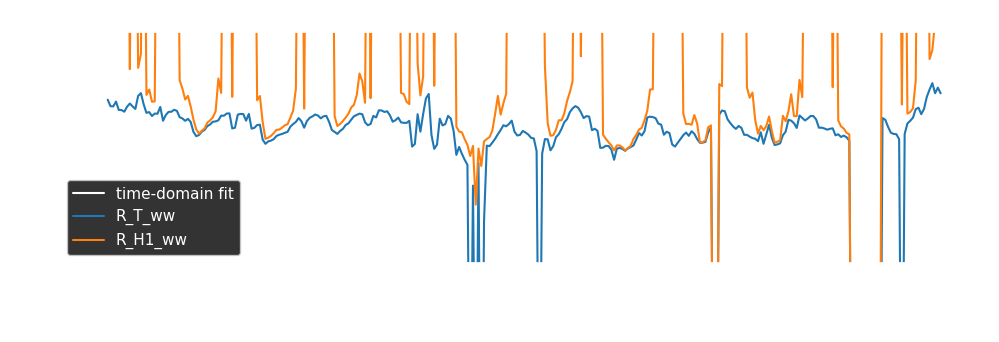

In [58]:
fig, ax = plt.subplots(figsize=(12,3))
ax.set_yscale('log')
ax.plot(a.index, a, lw=1.5, alpha=1, color='w', label='time-domain fit')
#trf_fit.sel(var=['R_H1']).plot(ax=ax, lw=5)
#trf_fit.sel(var=['R_T']).plot(ax=ax, lw=5)
trf_fit.sel(var=['R_T_ww']).plot(ax=ax, label='R_T_ww')
trf_fit.sel(var=['R_H1_ww']).plot(ax=ax, label='R_H1_ww')
ax.set_ylim(1e-1, 1e6)
ax.legend()

In [8]:
xarr = multitaper.om.cross_spectrogram(sig_interp, dt=dt, twin=twin, olap=olap, nw=nw, kspec=k)

Window length 2419200.0s and overlap 75%
Total number of cross-spectral estimates 603
Frequency band of interest ( 0.00- 0.00)Hz
Loop  10  of  603
Loop  20  of  603
Loop  30  of  603
Loop  40  of  603
Loop  50  of  603
Loop  60  of  603
Loop  70  of  603
Loop  80  of  603
Loop  90  of  603
Loop  100  of  603
Loop  110  of  603
Loop  120  of  603
Loop  130  of  603
Loop  140  of  603
Loop  150  of  603
Loop  160  of  603
Loop  170  of  603
Loop  180  of  603
Loop  190  of  603
Loop  200  of  603
Loop  210  of  603
Loop  220  of  603
Loop  230  of  603
Loop  240  of  603
Loop  250  of  603
Loop  260  of  603
Loop  270  of  603
Loop  280  of  603
Loop  290  of  603
Loop  300  of  603
Loop  310  of  603
Loop  320  of  603
Loop  330  of  603
Loop  340  of  603
Loop  350  of  603
Loop  360  of  603
Loop  370  of  603
Loop  380  of  603
Loop  390  of  603
Loop  400  of  603
Loop  410  of  603
Loop  420  of  603
Loop  430  of  603
Loop  440  of  603
Loop  450  of  603
Loop  460  of  603
Loop  

         18121758 function calls (18059551 primitive calls) in 40.286 seconds

   Ordered by: internal time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
     1206    7.851    0.007   11.795    0.010 utils.py:736(adaptspec)
  2748200    7.787    0.000    7.787    0.000 {built-in method cythonized.sft}
      603    6.534    0.011   38.028    0.063 mtcross.py:137(__init__)
      604    3.915    0.006    3.944    0.007 _decomp.py:1189(eigh_tridiagonal)
   153976    3.346    0.000    3.346    0.000 {method 'reduce' of 'numpy.ufunc' objects}
    21140    3.123    0.000   11.263    0.001 utils.py:135(xint)
1838038/1836223    1.205    0.000    5.529    0.000 {built-in method numpy.core._multiarray_umath.implement_array_function}
     1206    0.885    0.001    1.540    0.001 utils.py:646(eigenspec)
     1206    0.524    0.000    0.524    0.000 {built-in method scipy.fft._pocketfft.pypocketfft.c2c}
  2748200    0.336    0.000    8.123    0.000 utils.py:1770(sft)
   81

In [9]:
bad_slices = (~slices_ok).tolist()
def set_to_nan(da, bad_slices):
    da1 = da.copy()
    da1.loc[:,bad_slices,:] *= np.nan
    return da1
xarr_nan = set_to_nan(xarr, bad_slices=~slices_ok)
sl = slice(2/3 /(24*60**2), 3/2 /(24*60**2))

Text(0.5, 1.0, '$\\hat{S}_{xx}$')

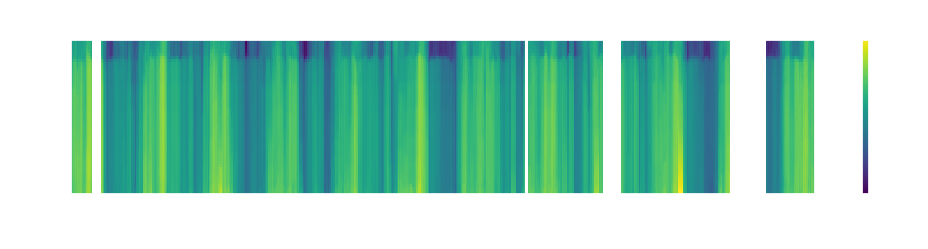

In [10]:
fig, ax = plt.subplots(figsize=(12, 2))
(
    xarr_nan.sel(var='Sxx', f=sl)
).real.plot.pcolormesh(cmap='viridis', norm=mcolors.LogNorm(), ax=ax)
ax.xaxis.set_major_locator(mdates.YearLocator(base=1))
ax.set_xlabel('')
ax.set_title(r'$\hat{S}_{xx}$')

Text(0.5, 1.0, '$\\hat{S}_{yy}$')

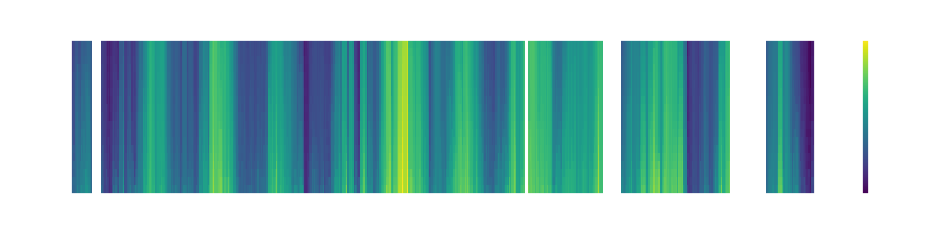

In [12]:
fig, ax = plt.subplots(figsize=(12, 2))
sl = slice(2/3/(24*60**2), 1/(24*60**2))
(
    xarr_nan.sel(var='Syy', f=sl).real
).real.plot.pcolormesh(cmap='viridis', norm=mcolors.LogNorm(), ax=ax)
ax.xaxis.set_major_locator(mdates.YearLocator(base=1))
ax.set_xlabel('')
ax.set_title(r'$\hat{S}_{yy}$')

Text(0.5, 1.0, '$Tyx=\\sqrt{\\hat{S}_{yy}/\\hat{S}_{xx}}$')

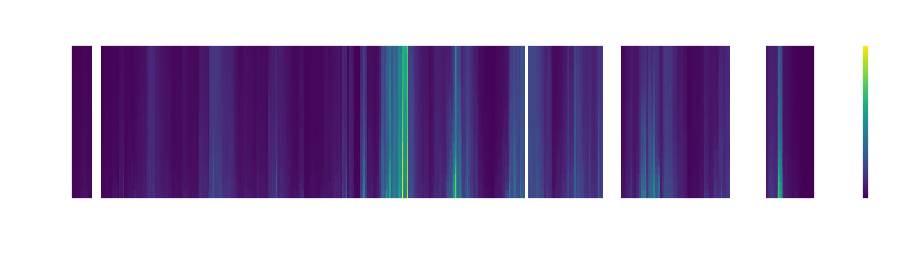

In [13]:
fig, ax = plt.subplots(figsize=(12, 2))
(
    np.sqrt(xarr_nan.sel(var='Syy', f=sl).real)
    / np.sqrt(xarr_nan.sel(var='Sxx', f=sl).real)
).real.plot.pcolormesh(cmap='viridis', norm=mcolors.Normalize(), ax=ax)
ax.xaxis.set_major_locator(mdates.YearLocator(base=1))
ax.set_xlabel('')
ax.set_title(r'$Tyx=\sqrt{\hat{S}_{yy}/\hat{S}_{xx}}$')

Text(0.5, 1.0, '$Tyx^2=\\hat{S}_{yy}/\\hat{S}_{xx}$')

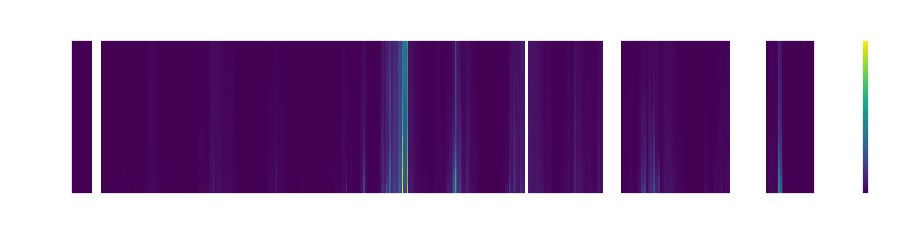

In [60]:
fig, ax = plt.subplots(figsize=(12, 2))
(
    xarr_nan.sel(var='Syy', f=sl)
    / xarr_nan.sel(var='Sxx', f=sl)
).real.plot.pcolormesh(cmap='viridis', norm=mcolors.Normalize(), ax=ax)
ax.xaxis.set_major_locator(mdates.YearLocator(base=1))
ax.set_xlabel('')
ax.set_title(r'$Tyx^2=\hat{S}_{yy}/\hat{S}_{xx}$')

Text(0.5, 1.0, '$Cyx=\\hat{S}_{yx}/\\sqrt{\\hat{S}_{yy}\\hat{S}_{xx}}$')

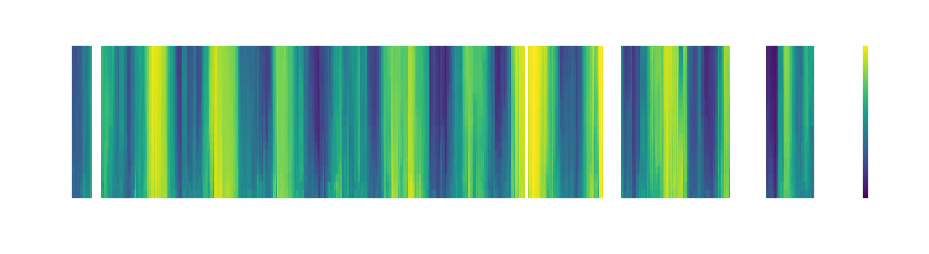

In [14]:
fig, ax = plt.subplots(figsize=(12, 2))
(
    xarr_nan.sel(var='Syx', f=sl)
    / np.sqrt(xarr_nan.sel(var='Syy', f=sl) * xarr_nan.sel(var='Sxx', f=sl))
).real.plot.pcolormesh(cmap='viridis', norm=mcolors.Normalize(), ax=ax)
ax.xaxis.set_major_locator(mdates.YearLocator(base=1))
ax.set_xlabel('')
ax.set_title(r'$Cyx=\hat{S}_{yx}/\sqrt{\hat{S}_{yy}\hat{S}_{xx}}$')

Text(0.5, 1.0, '$\\hat{H}_1=\\hat{S}_{yx}/\\hat{S}_{xx}$')

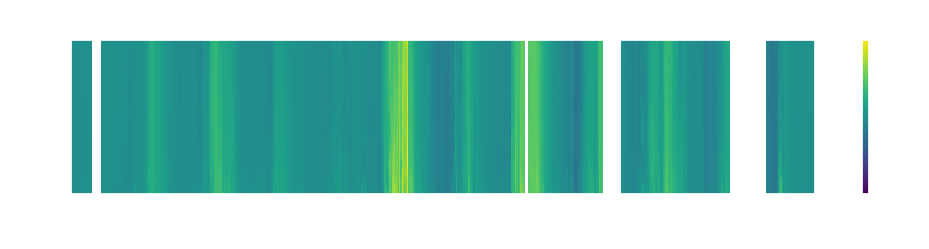

In [15]:
fig, ax = plt.subplots(figsize=(12, 2))
(
    xarr_nan.sel(var='Syx', f=sl)
    / xarr_nan.sel(var='Sxx', f=sl)
).real.plot.pcolormesh(cmap='viridis', norm=mcolors.Normalize(), ax=ax)
ax.xaxis.set_major_locator(mdates.YearLocator(base=1))
ax.set_xlabel('')
ax.set_title(r'$\hat{H}_1=\hat{S}_{yx}/\hat{S}_{xx}$')

Text(0.5, 1.0, '$\\hat{H}_2=\\hat{S}_{yy}/\\hat{S}_{yx}$')

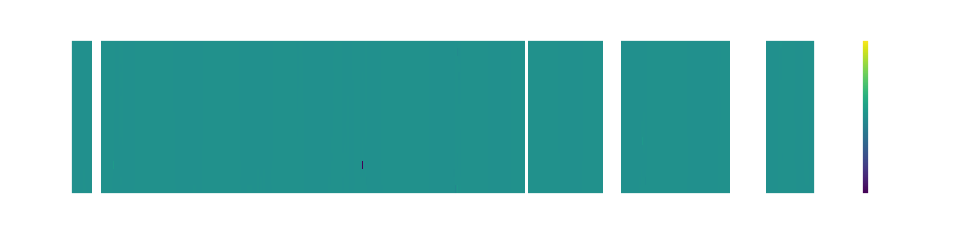

In [16]:

fig, ax = plt.subplots(figsize=(12, 2))
(
    xarr_nan.sel(var='Syy', f=sl).real
    / xarr_nan.sel(var='Syx', f=sl).real
).real.plot.pcolormesh(cmap='viridis', norm=mcolors.Normalize(), ax=ax)
ax.xaxis.set_major_locator(mdates.YearLocator(base=1))
ax.set_xlabel('')
ax.set_title(r'$\hat{H}_2=\hat{S}_{yy}/\hat{S}_{yx}$')

/home/olivier/.pyenv/versions/3.9.9/envs/.venv/lib/python3.9/site-packages/xarray/core/computation.py:771: RuntimeWarning: invalid value encountered in sqrt
  result_data = func(*input_data)


Text(0.5, 1.0, '$R(\\hat{T}_{yx}^2)$')

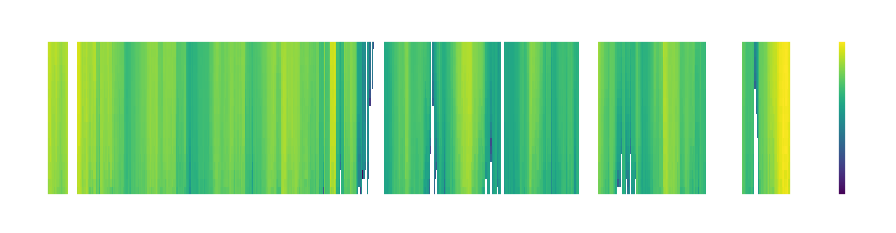

In [61]:
fig, ax = plt.subplots(figsize=(12, 2))

da1 = xarr_nan.sel(var='Sxx', f=sl).real
da2 = xarr_nan.sel(var='Syy', f=sl).real

R1 = ww.resistance_spectrum(
        da1, da2,
        2*np.pi*np.tile(da1.coords['f'], (da1.shape[1], 1)).T,
        45, 10, min_r=None
    )

pcm = ax.pcolormesh(
    da1.coords['t'],
    da1.coords['f'],
    R1, cmap='viridis', norm=mcolors.LogNorm()
)
plt.colorbar(pcm)

ax.xaxis.set_major_locator(mdates.YearLocator(base=1))
ax.set_xlabel('')
ax.set_title(r'$R(\hat{T}_{yx}^2)$')

/home/olivier/.pyenv/versions/3.9.9/envs/.venv/lib/python3.9/site-packages/xarray/core/computation.py:771: RuntimeWarning: invalid value encountered in sqrt
  result_data = func(*input_data)


Text(0.5, 1.0, '$R(\\hat{H}_{1})$')

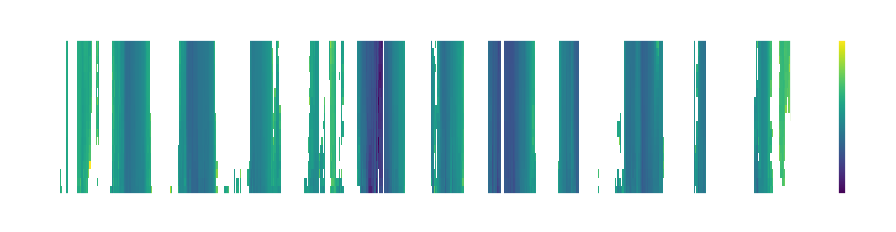

In [62]:
fig, ax = plt.subplots(figsize=(12, 2))
sl = slice(2/3/(24*60**2), 1/(24*60**2))

da1 = xarr_nan.sel(var='Sxx', f=sl).real
da2 = xarr_nan.sel(var='Syx', f=sl).real

R2 = ww.resistance_spectrum(
        da1, da2,
        2*np.pi*np.tile(da1.coords['f'], (da1.shape[1], 1)).T,
        45, 10, min_r=None
    )

pcm = ax.pcolormesh(
    da1.coords['t'],
    da1.coords['f'],
    R2, cmap='viridis', norm=mcolors.LogNorm()
)
plt.colorbar(pcm)

ax.xaxis.set_major_locator(mdates.YearLocator(base=1))
ax.set_xlabel('')
ax.set_title(r'$R(\hat{H}_{1})$')

/home/olivier/.pyenv/versions/3.9.9/envs/.venv/lib/python3.9/site-packages/xarray/core/computation.py:771: RuntimeWarning: invalid value encountered in sqrt
  result_data = func(*input_data)


Text(0.5, 1.0, '$R(\\hat{H}_{1}^2)$')

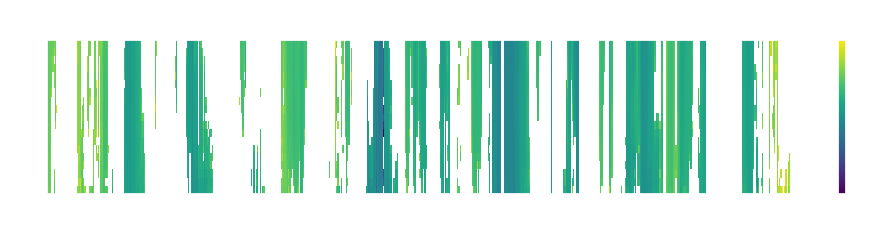

In [65]:
fig, ax = plt.subplots(figsize=(12, 2))
sl = slice(2/3/(24*60**2), 1/(24*60**2))

da1 = xarr_nan.sel(var='Sxx', f=sl)**2
da2 = xarr_nan.sel(var='Syx', f=sl)**2

R3 = ww.resistance_spectrum(
        da1.real, da2.real,
        2*np.pi*np.tile(da1.coords['f'], (da1.shape[1], 1)).T,
        45, 10, min_r=None
    )

pcm = ax.pcolormesh(
    da1.coords['t'],
    da1.coords['f'],
    R3, cmap='viridis', norm=mcolors.LogNorm()
)
plt.colorbar(pcm)

ax.xaxis.set_major_locator(mdates.YearLocator(base=1))
ax.set_xlabel('')
ax.set_title(r'$R(\hat{H}_{1}^2)$')

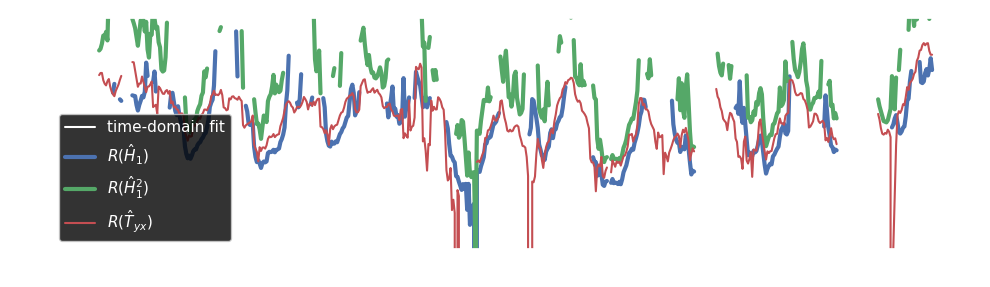

In [66]:
fig, ax = plt.subplots(figsize=(12, 3))
with pd.HDFStore('../../../PycharmProjects/orca5/data/output/2346__150__.h5') as store:
    a = 10**store.piezo.popt.tz_convert(None)['2011':]
ax.semilogy(a.index, a, lw=1.5, alpha=1, color='w', label='time-domain fit')
ax.semilogy(da1.coords['t'], np.mean(R2, axis=0), lw=3, alpha=1, color='b', label=r'$R(\hat{H}_{1})$')
ax.semilogy(da1.coords['t'], np.mean(R3, axis=0), lw=3, alpha=1, color='g', label=r'$R(\hat{H}_{1}^2)$')
ax.semilogy(da1.coords['t'], np.mean(R1, axis=0), lw=1.5, alpha=1, color='r', label=r'$R(\hat{T}_{yx})$')

ax.xaxis.set_major_locator(mdates.YearLocator(base=1))
ax.set_ylim(1e1, 1e5)
#ax.grid(zorder=-1)
ax.legend()


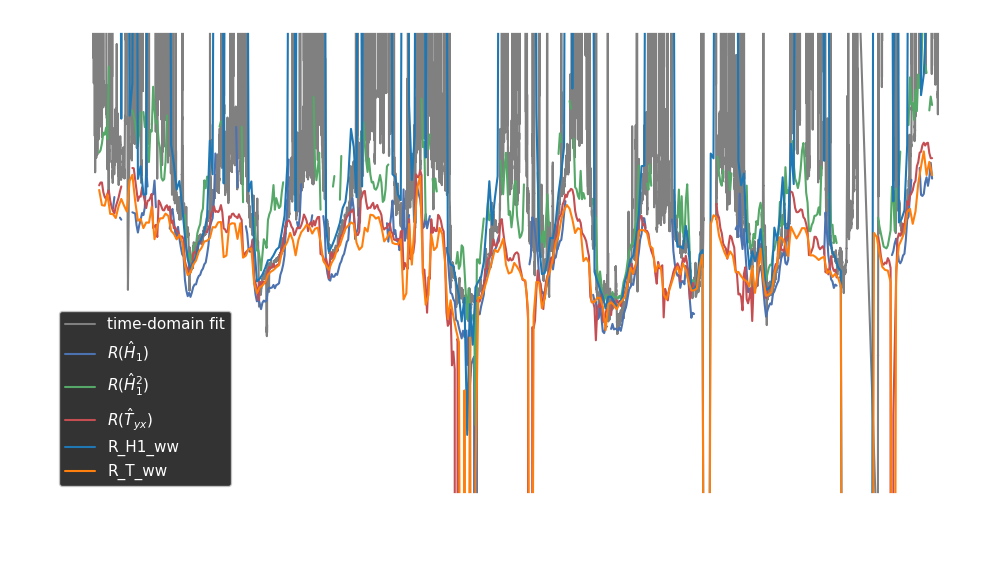

In [67]:
fig, ax = plt.subplots(figsize=(12, 6))
with pd.HDFStore('../../../PycharmProjects/orca5/data/output/2346__150__.h5') as store:
    a = 10**store.piezo.popt.tz_convert(None)['2011':]
ax.semilogy(a.index, a, lw=1.5, alpha=1, color='0.5', label='time-domain fit')
ax.semilogy(da1.coords['t'], np.mean(R2, axis=0), lw=1.5, alpha=1, color='b', label=r'$R(\hat{H}_{1})$')
ax.semilogy(da1.coords['t'], np.mean(R3, axis=0), lw=1.5, alpha=1, color='g', label=r'$R(\hat{H}_{1}^2)$')
ax.semilogy(da1.coords['t'], np.mean(R1, axis=0), lw=1.5, alpha=1, color='r', label=r'$R(\hat{T}_{yx})$')
trf_fit.sel(var=['R_H1_ww']).plot(ax=ax, label='R_H1_ww')
trf_fit.sel(var=['R_T_ww']).plot(ax=ax, label='R_T_ww')

ax.xaxis.set_major_locator(mdates.YearLocator(base=1))
ax.set_ylim(1e0, 1e6)
#ax.grid(zorder=-1)
ax.legend()


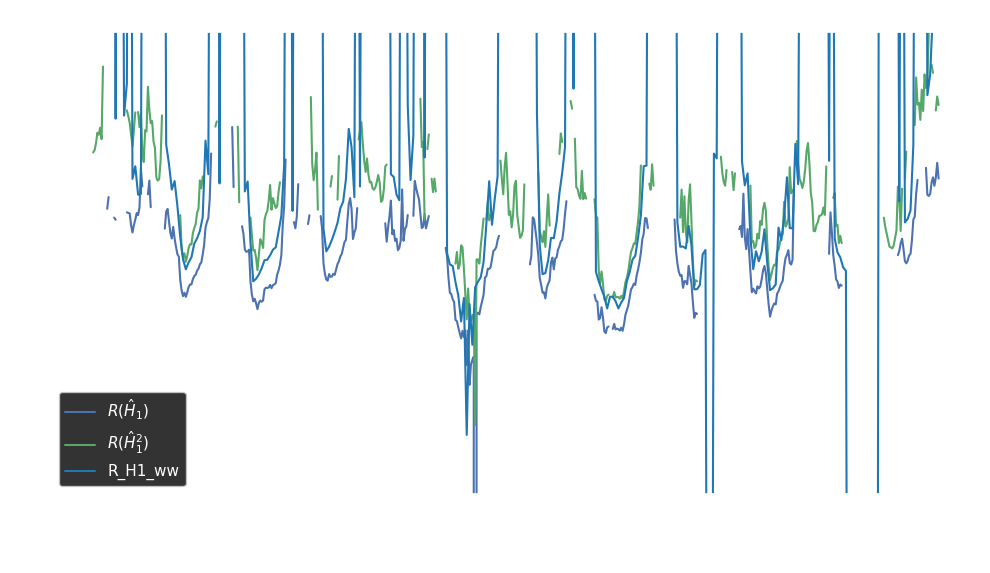

In [69]:
fig, ax = plt.subplots(figsize=(12, 6))
with pd.HDFStore('../../../PycharmProjects/orca5/data/output/2346__150__.h5') as store:
    a = 10**store.piezo.popt.tz_convert(None)['2011':]
# ax.semilogy(a.index, a, lw=1.5, alpha=1, color='0.5', label='time-domain fit')
ax.semilogy(da1.coords['t'], np.mean(R2, axis=0), lw=1.5, alpha=1, color='b', label=r'$R(\hat{H}_{1})$')
ax.semilogy(da1.coords['t'], np.mean(R3, axis=0), lw=1.5, alpha=1, color='g', label=r'$R(\hat{H}_{1}^2)$')
#ax.semilogy(da1.coords['t'], np.mean(R1, axis=0), lw=1.5, alpha=1, color='r', label=r'$R(\hat{T}_{yx})$')
trf_fit.sel(var=['R_H1_ww']).plot(ax=ax, label='R_H1_ww')
#trf_fit.sel(var=['R_T_ww']).plot(ax=ax, label='R_T_ww')

ax.xaxis.set_major_locator(mdates.YearLocator(base=1))
ax.set_ylim(1e0, 1e6)
#ax.grid(zorder=-1)
ax.legend()

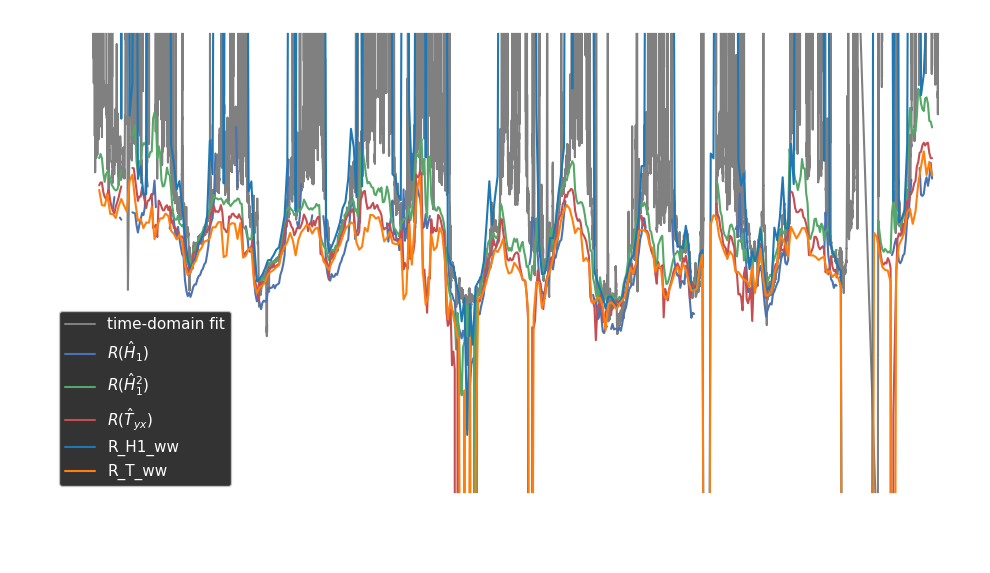

In [48]:
fig, ax = plt.subplots(figsize=(12, 6))
with pd.HDFStore('../../../PycharmProjects/orca5/data/output/2346__150__.h5') as store:
    a = 10**store.piezo.popt.tz_convert(None)['2011':]
ax.semilogy(a.index, a, lw=1.5, alpha=1, color='0.5', label='time-domain fit')
ax.semilogy(da1.coords['t'], np.mean(R2, axis=0), lw=1.5, alpha=1, color='b', label=r'$R(\hat{H}_{1})$')
ax.semilogy(da1.coords['t'], np.mean(R3, axis=0), lw=1.5, alpha=1, color='g', label=r'$R(\hat{H}_{1}^2)$')
ax.semilogy(da1.coords['t'], np.mean(R1, axis=0), lw=1.5, alpha=1, color='r', label=r'$R(\hat{T}_{yx})$')
trf_fit.sel(var=['R_H1_ww']).plot(ax=ax, label='R_H1_ww')
trf_fit.sel(var=['R_T_ww']).plot(ax=ax, label='R_T_ww')

ax.xaxis.set_major_locator(mdates.YearLocator(base=1))
ax.set_ylim(1e0, 1e6)
#ax.grid(zorder=-1)
ax.legend()

Je veux voire la courbe du fit dans le domaine fréquentiel superposée!

In [73]:
np.sqrt(1j)

(0.7071067811865476+0.7071067811865476j)

In [20]:
nw = 12
window = sig_with_nan['gh'].size
k = 2*nw-1
tapers, lambdas = libtfr.dpss(window, nw, k)


NameError: name 'sig_with_nan' is not defined

In [ ]:
lambdas


array([1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       0.99999995, 0.99999946, 0.99999431, 0.99994647, 0.99955324,
       0.99673423, 0.97972382, 0.90099705])

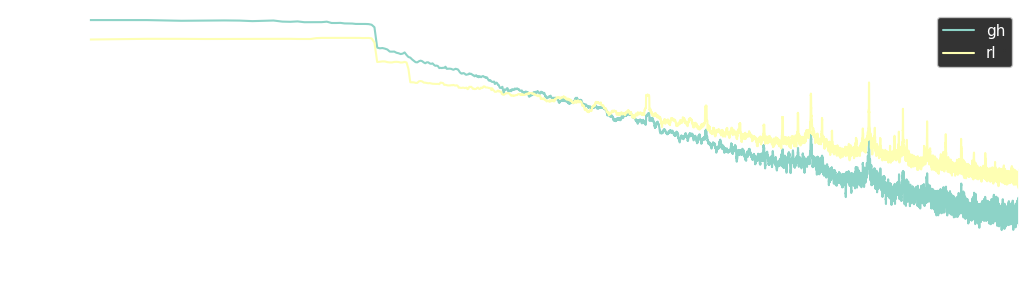

In [ ]:
# specta estimation and plot
nw = 12
window = sig_with_nan['gh'].size
k = 2*nw-1
transform = libtfr.mfft_dpss(
    nfft=power_bit_length(window),  # number of points in the transform
    nw=nw,  # time-frequency parameter
    ntapers=k,  # number of tapers to generate (kspec = 2*nw-1)
    npoints=window,  # number of points in the taper (window)
)
sec_per_day = 24*60**2
Z = {}
fig, ax = plt.subplots(figsize=(12, 3))
for l, v in sig_with_nan.items():
    # transform a time series
    sig = resample_signal(sig_with_nan[l], sampling_period='H')
    Z[k] = transform.mtpsd(sig) / 24
    Fs = 1 / pd.to_timedelta(f'1{pd.infer_freq(sig.index)}').total_seconds()
    f, idx = libtfr.fgrid(Fs, transform.nfft)  # frequencies in Hz
    f1 = f * sec_per_day
    ax.loglog(f1, Z[k][idx], label=l)
    ax.set_xlim(f1[1], f1[-1])
ax.set_ylabel(r'PSD [m$^2$ day]')
ax.set_xlabel('Frequency [cycle/day]')
ax.legend()
ax.grid()
# sig2 = resample_signal(sig_with_nan['gh'], sampling_period='H')
# freqs2 = np.fft.rfftfreq(sig2.size, d=60**2) * sec_per_day
# print(freqs2)
# fft2 = np.fft.rfft(sig2)
# psd2 = np.abs(fft2)**2 / sec_per_day
# ax.plot(freqs2, np.abs(psd2), zorder=-1)
# ax.set_ylim(1e-8, 1e3)


J'obtiens des résultats identiques à ceux obtenus avec la toolbox de Prieto.
Le PSD obtenu avec la fonction "mtpsd" est en unité du signal au carré multiplié par le pas de temps d'échantillonage. Dans mon cas, comme le pas de temps de mesure est d'une heure, le PSD est retourné en [m$^2$ hour]. Je le divise par 24 pour avoir des [m$^2$ day].

In [ ]:
window = 1*28*24
nfft = power_bit_length(window)
shift = window//4
nw = 12
k = int(2*nw-1)
dates, freqs, Zdict = get_rl_and_gh_spectograms(
    sig_with_nan, nfft, nw, k, window, shift)


Pour le graphique il faut changer l'uninté des spectrograms ([m$^2$ hour] -> [m$^2$ day]) et celle des fréquences ([Hz] -> [cycle/day]).

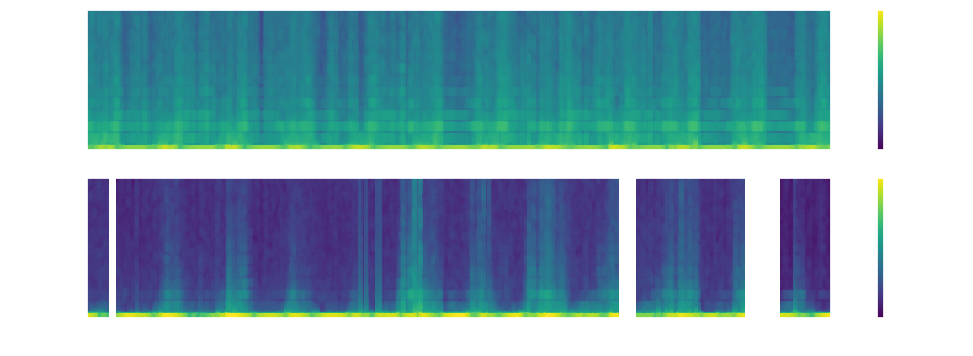

In [ ]:
plot_rl_and_gh_spectrograms(dates, freqs*sec_per_day, {k: v/24 for k, v in Zdict.items()},
                            ylabel='Frequency\n[cycle/day]',
                            cbar=True,
                            cblabel=r'PSD [m$^2$ day]',
                            cmap='viridis',
                            figsize=(12, 4))


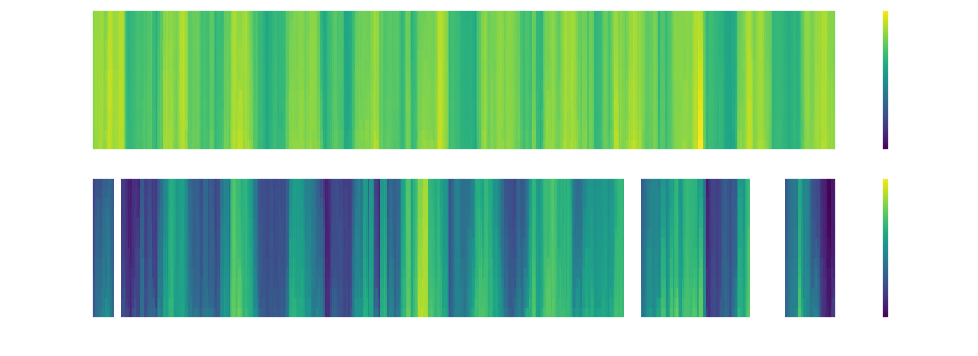

In [ ]:
Zdict1 = {}
for k in ['rl', 'gh']:
    dates1,  freqs1, Zdict1[k] = cut_spectrogram(
        dates, freqs*sec_per_day, Zdict[k]/24, ymin=2/3, ymax=1
    )

plot_rl_and_gh_spectrograms(dates1, freqs1, Zdict1,
                            ylabel='Frequency\n[cycle/day]',
                            cblabel=r'PSD [m$^2$ day]',
                            cmap='viridis',
                            figsize=(12, 4))


In [ ]:
alpha = 10  # diffusivity
omega = 2*np.pi*freqs[1:]
omega = np.tile(omega, (Zdict['rl'][1:, :].shape[1], 1)).T
print(Zdict['rl'][1:, :]/Zdict['gh'][1:, :])
R = ww.resistance_spectrum(
    Zdict['rl'][1:, :], Zdict['gh'][1:, :], omega, x=45, a=alpha, min_r=None
)


[[2.18903881e-02 2.67366389e-02 2.80015499e-02 ... 2.16983968e-02
  2.92742276e-02 3.97187022e-02]
 [2.18671694e-02 2.66246038e-02 2.80456713e-02 ... 2.14492778e-02
  2.88354915e-02 3.95750387e-02]
 [2.20316412e-02 2.64930801e-02 2.77521618e-02 ... 2.12476002e-02
  2.90448760e-02 3.91128640e-02]
 ...
 [1.55164101e+02 9.74519776e+01 1.64095765e+02 ... 2.97986865e+03
  1.50557185e+03 1.19828128e+03]
 [1.56996366e+02 1.02280293e+02 1.56930101e+02 ... 2.63354252e+03
  1.45313006e+03 1.23290937e+03]
 [1.66570281e+02 1.06165447e+02 1.58081548e+02 ... 2.49037340e+03
  1.44011427e+03 1.20081786e+03]]


/home/olivier/devel/multitaper/multitaper/examples/../../../PycharmProjects/orca5/src/wangwoerman/wangwoerman.py:107: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt(sqrt_term) - 1


$\alpha$ [m$^2$/s]; $\omega=2\pi f$ [rad/s]; R [m]

/tmp/ipykernel_133069/2731900590.py:115: RuntimeWarning: invalid value encountered in log
  a = np.log(x)
/tmp/ipykernel_133069/2731900590.py:116: RuntimeWarning: Mean of empty slice
  return np.exp(np.nanmean(a, axis=0))


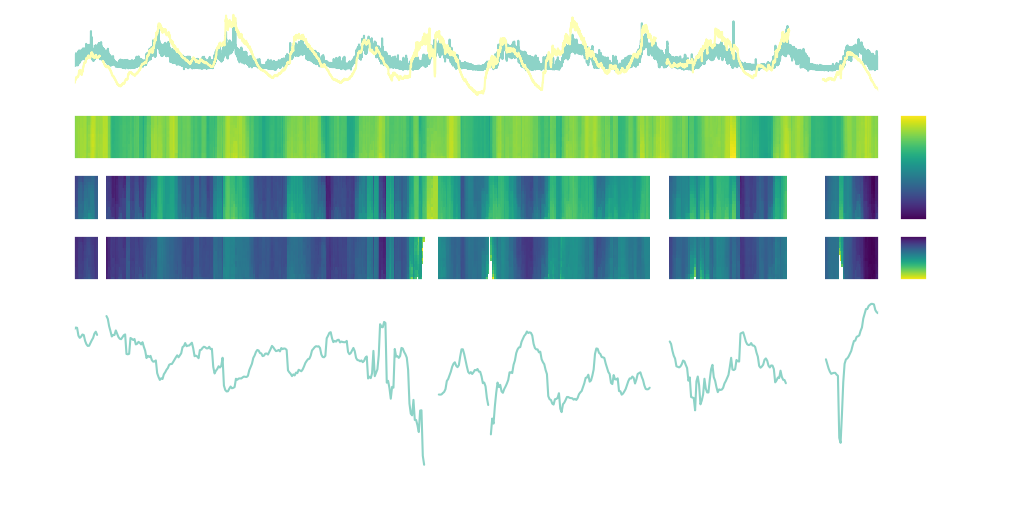

In [ ]:
spec_dict = {'rl': {'dates': None, 'freqs': None, 'Z': None},
             'gh': {'dates': None, 'freqs': None, 'Z': None}}
for k, v in spec_dict.items():
    v['dates'], v['freqs'], v['Z'] = cut_spectrogram(
        dates, freqs*sec_per_day, Zdict[k]/24, ymin=2/3, ymax=1
    )
R_dict = {'dates': None, 'freqs': None, 'R': None}
R_dict['dates'], R_dict['freqs'], R_dict['R'] = cut_spectrogram(
    dates, freqs[1:]*sec_per_day, R, ymin=2/3, ymax=1
)

plot_series_spetra_a(
    ser_dict=sig_with_nan, spec_dict=spec_dict, R_dict=R_dict,
    cmap='viridis'
)


Il y a des trous quand le modèle ne colle pas, c'est-à-dire, que le PSD de l'aquifère a des  valeures anormalement élevées par rapport à celui de la rivière.

Ce qui est étonnant, s'il on compare avec le fit de la fonction de transfert, c'est que les valeures maximales de a sont loin d'être aussi élevées. Or les valeures très élevées de a obtenue lors du fit de la fonction de transfert le sont en raison semble-t-il d'une fonctions de transfert expérimentale négative. Peut-être y-a-t'il un problème avec le calcul de la fonction de transfert? Ce serait bien de calculer la fonction de transfert ici.

Donc il existe quatre formules pour estimer une fonction de transfert (https://vru.vibrationresearch.com/lesson/transfer-function/). Trois d'entre elles font intervenir la densité spectrale de puissance croisée (CPSD) qui peut avoir des valeus négatives. La dernière, toujours positive, est définie comme la racine carrée du ration entre les PSDs (spectral ratio).
J'ai l'impression que la solution spectrale donnée pour R est plus apparentée à cette dernière façon d'estimer la fonction de transfert.

Serait-il possible de trouver une solution spectrale pour R qui soit plutôt apparentée à l'une des autres méthodes d'estimation de la fonction de transfert? Il suffit de remplacer Pr/P par n'importe quelle définition de la fonction de transfert élevée au carré!

In [ ]:
help(libtfr)


Help on module libtfr:

NAME
    libtfr - Interface to libtfr spectrogram library using numpy.

DESCRIPTION
    Spectrograms are returned as 2D arrays with frequency indexed by row and time by
    column. Signals are assumed to be real; therefore real power spectrograms with a
    transform size of N have N/2+1 rows, corresponding to frequencies from 0 to
    Nyquist. The number of time points in the spectrogram is (M - W + 1)/S, where M
    is the length of the signal, S is the shift (S), and the analysis window size is
    W (this may be less than or equal to N). Only time points corresponding to
    window positions that completely overlap with the signal are returned.
    
    Copyright C Daniel Meliza 2010-2016.  Licensed for use under GNU
    General Public License, Version 2.  See COPYING for details.

CLASSES
    builtins.object
        mfft
    
    class mfft(builtins.object)
     |  Computes multi-tapered transforms of real signals. Instantiate with factory
     |  functions

Il est plus facile de modifier le code de Prieto car il est entièrement en Python. Par contre il est beaucoup plus lent que celui de 
Meliza, essentiellement écrit en C. Dans un premier temps j'ai modifié le code de Prieto pour avoir des résultats rapides. Etant donné que les résultats sont probants, je suis tanté de soit, modifié celui de Meliza en fonction de mes besoins, soit, créer entièrement un code en C++ sur la base de celui de Prieto. En attendant je devrais prendre connaissance de ce que le code de Meliza a de particulier.
